In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def make_canvas(
    axes_width_pt: float = 300.0,
    axes_aspect: float = 2/3,
    left_pt: float = 40.0,
    right_pt: float = 20.0,
    bottom_pt: float = 35.0,
    top_pt: float = 20.0,
    fontsize: float = 8.0,
):
    _PT_PER_IN = 72.0
    # Use PDF “base 14” fonts (Helvetica) — no TTF embedding, no fontTools warnings
    plt.rcParams.update({
        "pdf.use14corefonts": True,   # key line
        "ps.useafm": True,            # for .ps if you ever use it
        # Do NOT set pdf.fonttype/ps.fonttype when using core fonts
        "text.usetex": False,         # set True only if you want LaTeX (see Option C)
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica"],
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
    })
    # Make math text look sans-ish to match Helvetica
    plt.rcParams.update({
        "mathtext.fontset": "stixsans",
    })

    axes_h_pt = axes_width_pt * float(axes_aspect)
    fig_w_pt = left_pt + axes_width_pt + right_pt
    fig_h_pt = bottom_pt + axes_h_pt + top_pt

    fig = plt.figure(figsize=(fig_w_pt/_PT_PER_IN, fig_h_pt/_PT_PER_IN))
    ax = fig.add_axes([
        left_pt/fig_w_pt,
        bottom_pt/fig_h_pt,
        axes_width_pt/fig_w_pt,
        axes_h_pt/fig_h_pt,
    ])
    # ax.grid(True, which="both", linestyle=":", linewidth=0.5)
    return fig, ax

/var/folders/3h/bnfdmp3n4jxctbk9z3l__ns40000gn/T/ipykernel_54828/3182624359.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


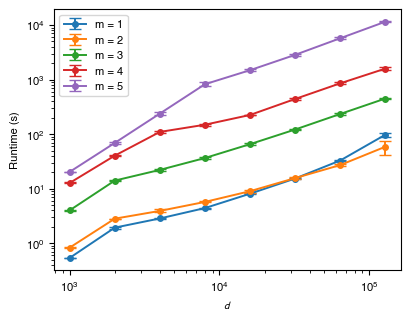

In [18]:
# Load CSV
records = []
with open("time_list.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        m = int(row["m"])
        d = int(row["d"])
        t = float(row["runtime"])
        records.append((m, d, t))

records = np.array(records, dtype=[("m", int), ("d", int), ("t", float)])

m_list = np.unique(records["m"])
d_list = np.unique(records["d"])

# Compute mean and std for each (m, d)
stats = {}
for m in m_list:
    for d in d_list:
        ts = records[(records["m"] == m) & (records["d"] == d)]["t"]
        if len(ts) > 0:
            stats[(m, d)] = (np.mean(ts), np.std(ts))
        else:
            stats[(m, d)] = (np.nan, np.nan)

# Plot
fig, ax = make_canvas(axes_width_pt=250.0, axes_aspect=3/4)

for m in m_list:
    means = []
    stds = []
    for d in d_list:
        mean, std = stats[(m, d)]
        means.append(mean)
        stds.append(std)
    ax.errorbar(
        d_list,
        means,
        yerr=stds,
        marker="o",
        markersize=4,
        capsize=4,
        label=f"m = {m}",
        linewidth=1.4,
    )

ax.set_xlabel(r"$d$")
ax.set_ylabel("Runtime (s)")
# ax.title("Compressor Runtime vs d (mean ± 1 std)")
ax.set_xscale("log")
ax.set_yscale("log")
# ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend()
plt.tight_layout()
fig.savefig('runtime_plot.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

In [18]:
np.log(32000)**2*20

2152.186385970122